In [ ]:
%pip install pandas

#**SECCION #1 ESCALAMIENTO**

#**DESCRIPCION DEL DATASET**
Este dataset representa la información de clientes de una Empresa, con el objetivo de analizar su comportamiento de compra. Cada fila corresponde a un cliente y cada columna describe una caracteristica del mismo. Cada columna representa una caracteristica del cliente.

1.*Variable Explicativa (X)
Son las variables que usamos para predecir.
**Edad** Edad del Cliente en años
**IngresoMensual**ingreso del cliente (en miles o unidades monetarias), representa la capacidad económica.
**CantidadCompras**
Número de compras realizadas por el cliente en el pasado, es un indicador de comportaniento histórico.
**Ciudad**
Ciudad donde reside el cliente.
Es una variable categórica(texto).
____________________________________________________________________
**Variable objetivo (Y)**
**Compra**
Es la variable que queremos predecir, representa si el cliente realizó una compra en un momento específico(por ejemplo, una campaña o visita ).
**Valores**:
* 1. El cliente si compró
* 2. El cliente no compró


#**Importar Librerias**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

#**Creamos el Dataset**


In [59]:
data = {
    "Edad": [23, 35, 29, 41, 33, 27, 38, 31, 45, 22],
    "IngresoMensual": [1200, 3500, 2200, 4800, 3100, 1800, 4200, 2600, 7000, 1000],
    "CantidadCompras": [2, 8, 5, 12, 7, 3, 10, 6, 15, 1],
    "Ciudad": ["Bogotá", "Cali", "Medellín", "Bogotá", "Barranquilla", "Cali", "Medellín", "Bogotá", "Cali", "Barranquilla"],
    "Compra": [0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)
df


,Edad,IngresoMensual,CantidadCompras,Ciudad,Compra
0,23,1200,2,Bogotá,0
1,35,3500,8,Cali,1
2,29,2200,5,Medellín,0
3,41,4800,12,Bogotá,1
4,33,3100,7,Barranquilla,1
5,27,1800,3,Cali,0
6,38,4200,10,Medellín,1
7,31,2600,6,Bogotá,0
8,45,7000,15,Cali,1
9,22,1000,1,Barranquilla,0


#**Diagnóstico inicial del dataset**
Antes de escalar, debemos identificar 
1. Que columnas son numéricas
2. Que columnas son categóricas 
3. Cual es la variable objetivo
4. Que columnas no deben escalarse

In [6]:
df.dtypes


Edad               int64
IngresoMensual     int64
CantidadCompras    int64
Ciudad               str
Compra             int64
dtype: object

In [7]:
df.describe()

,Edad,IngresoMensual,CantidadCompras,Compra
count,10.000000,10.000000,10.000000,10.000000
mean,32.400000,3140.000000,6.900000,0.500000
std,7.530678,1832.545285,4.483302,0.527046
min,22.000000,1000.000000,1.000000,0.000000
25%,27.500000,1900.000000,3.500000,0.000000
50%,32.000000,2850.000000,6.500000,0.500000
75%,37.250000,4025.000000,9.500000,1.000000
max,45.000000,7000.000000,15.000000,1.000000


#**OBSERVACIONES**

En el siguiente describe, podemos observar que los valores que corresponden a ingresos mensual tienen valores mucho más altos que edad y cantidad de compras, esto corresponde a una diferencia de unidades de medida, es importante recalcar que debemos realizar escalado 

#**Comparación Visual antes de escalar**
Vamos a visualizar las variables numéricas en su escala original

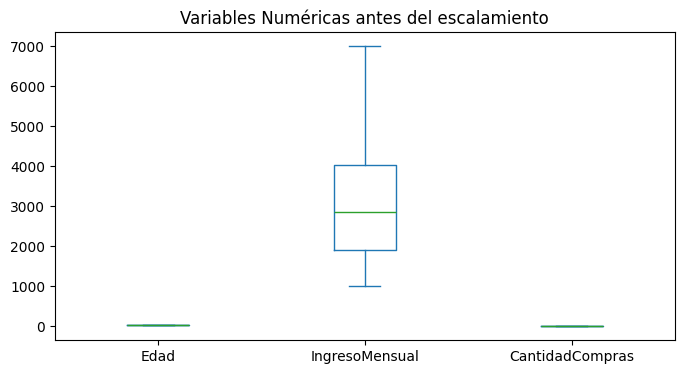

In [8]:
columnas_numericas = ["Edad", "IngresoMensual", "CantidadCompras"]
df[columnas_numericas].plot(kind="box",figsize=(8,4))
plt.title("Variables Numéricas antes del escalamiento")
plt.show()

#**Interpretación**
En el grafico se puede observar claramente que el IngresoMensual, domina visualmente porque sus valores son muchos más grandes. esto permite ver porque es tan importante aplicar escalado antes de usar cualquier modelo.

#**Técnica StandardScaler**

In [9]:
scaler_standard = StandardScaler()
datos_standard = scaler_standard.fit_transform(df[columnas_numericas])
df_standard = pd.DataFrame(datos_standard,columns=[col+"_standard" for col in columnas_numericas])
df_standard
df


,Edad,IngresoMensual,CantidadCompras,Ciudad,Compra
0,23,1200,2,Bogotá,0
1,35,3500,8,Cali,1
2,29,2200,5,Medellín,0
3,41,4800,12,Bogotá,1
4,33,3100,7,Barranquilla,1
5,27,1800,3,Cali,0
6,38,4200,10,Medellín,1
7,31,2600,6,Bogotá,0
8,45,7000,15,Cali,1
9,22,1000,1,Barranquilla,0


In [11]:
df


,Edad,IngresoMensual,CantidadCompras,Ciudad,Compra
0,23,1200,2,Bogotá,0
1,35,3500,8,Cali,1
2,29,2200,5,Medellín,0
3,41,4800,12,Bogotá,1
4,33,3100,7,Barranquilla,1
5,27,1800,3,Cali,0
6,38,4200,10,Medellín,1
7,31,2600,6,Bogotá,0
8,45,7000,15,Cali,1
9,22,1000,1,Barranquilla,0


#**Verificación Estadistica**
luego de aplicar StandardScaler procedemos a comprobar la media y la desviación estándar.

In [12]:
print("Media después de StandardScaler:")
print(df_standard.mean())

print("Desviación estándar después de StandardScaler:")
print(df_standard.std())


Media después de StandardScaler:
Edad_standard               1.998401e-16
IngresoMensual_standard    -4.440892e-17
CantidadCompras_standard   -8.881784e-17
dtype: float64
Desviación estándar después de StandardScaler:
Edad_standard               1.054093
IngresoMensual_standard     1.054093
CantidadCompras_standard    1.054093
dtype: float64


#**Nota importante**
La media queda muy cerca de O. la desviación estándar puede verse cercana a 1, aunque dependiendo del cálculo muestral o poblacional.

#**Comparación del Dataset original con el dataset escalado**
**Before/After con StandardScaler**
Ahora se comapara el dataset original con el dataset escalado.

In [13]:
comparacion_standard = pd.concat([df[columnas_numericas], df_standard], axis=1)
comparacion_standard


,Edad,IngresoMensual,CantidadCompras,Edad_standard,IngresoMensual_standard,CantidadCompras_standard
0,23,1200,2,-1.315747,-1.115901,-1.152065
1,35,3500,8,0.363930,0.207074,0.258627
2,29,2200,5,-0.475909,-0.540694,-0.446719
3,41,4800,12,1.203769,0.954843,1.199088
4,33,3100,7,0.083984,-0.023008,0.023512
5,27,1800,3,-0.755855,-0.770777,-0.916949
6,38,4200,10,0.783850,0.609719,0.728857
7,31,2600,6,-0.195962,-0.310612,-0.211604
8,45,7000,15,1.763661,2.220298,1.904433
9,22,1000,1,-1.455721,-1.230943,-1.387180


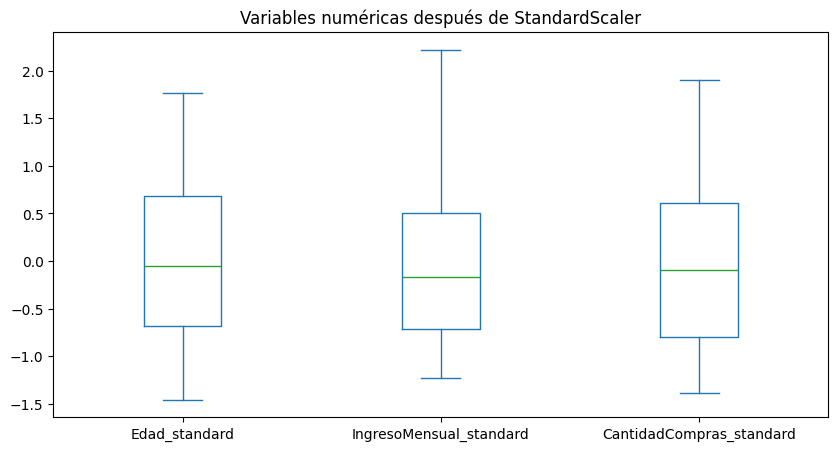

In [14]:
df_standard.plot(kind="box", figsize=(10, 5))
plt.title("Variables numéricas después de StandardScaler")
plt.show()

#**Conclusión**
los valores originales fueron transformados a una escala comun, ejemplo: una edad que antes aparecia con el numero 23, luego del scaler aparece como un valor relativo frente al promedio de edad. en cuanto al ingreso ya no aparece como 3500, sino como un valor relativo frente al promedio de ingresos. el significado estadistico cambia de "valor absoluto" a "posición relativa respecto a la media".

#**SECCIÓN # 2 CODIFICACIÓN**


#**Variables Categóricas del Dataset**


In [15]:
data = {
    "Edad": [23, 35, 29, 41, 33, 27, 38, 31, 45, 22],
    "IngresoMensual": [1200, 3500, 2200, 4800, 3100, 1800, 4200, 2600, 7000, 1000],
    "CantidadCompras": [2, 8, 5, 12, 7, 3, 10, 6, 15, 1],
    "Ciudad": ["Bogotá", "Cali", "Medellín", "Bogotá", "Barranquilla", "Cali", "Medellín", "Bogotá", "Cali", "Barranquilla"],
    "Compra": [0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
df

,Edad,IngresoMensual,CantidadCompras,Ciudad,Compra
0,23,1200,2,Bogotá,0
1,35,3500,8,Cali,1
2,29,2200,5,Medellín,0
3,41,4800,12,Bogotá,1
4,33,3100,7,Barranquilla,1
5,27,1800,3,Cali,0
6,38,4200,10,Medellín,1
7,31,2600,6,Bogotá,0
8,45,7000,15,Cali,1
9,22,1000,1,Barranquilla,0


#**Diagnóstico inicial del dataset**
Antes de codificar tenemos que identificar 
1. que columnas son categóricas
2. cuales son nominales.
3. cuales son ordinales.
4. que errores conceptuales podríamos cometer

In [17]:
df.dtypes


Edad               int64
IngresoMensual     int64
CantidadCompras    int64
Ciudad               str
Compra             int64
dtype: object

#**Interpretación del resultado**
Para realizar codificación a este dataset debo tener en cuenta que la única columna que se le puede aplicar es a la columna ciudad, ya que compra que en este caso seria la variable y u objetivo ya esta codificada. En el tipo de datos descubro que ciudad tiene el tipo str, esto indica 

#**Separamos las columnas por tipo**

In [20]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object","string"]).columns.tolist()

print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Columnas numéricas: ['Edad', 'IngresoMensual', 'CantidadCompras', 'Compra']
Columnas categóricas: ['Ciudad']


#**Conversion de Variables Categoricas Nominales: One-HotEncoding**

In [25]:
df_onehot = pd.get_dummies(df, columns=["Ciudad"], dtype=int)
df_onehot

,Edad,IngresoMensual,CantidadCompras,Compra,Ciudad_Barranquilla,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín
0,23,1200,2,0,0,1,0,0
1,35,3500,8,1,0,0,1,0
2,29,2200,5,0,0,0,0,1
3,41,4800,12,1,0,1,0,0
4,33,3100,7,1,1,0,0,0
5,27,1800,3,0,0,0,1,0
6,38,4200,10,1,0,0,0,1
7,31,2600,6,0,0,1,0,0
8,45,7000,15,1,0,0,1,0
9,22,1000,1,0,1,0,0,0


#**Visualización conceptual del One-Hot**
Visualizamos cuantas veces aparece cada ciudad ayuda a relacionar la frecuencia observada con las columnas binarias creadas.

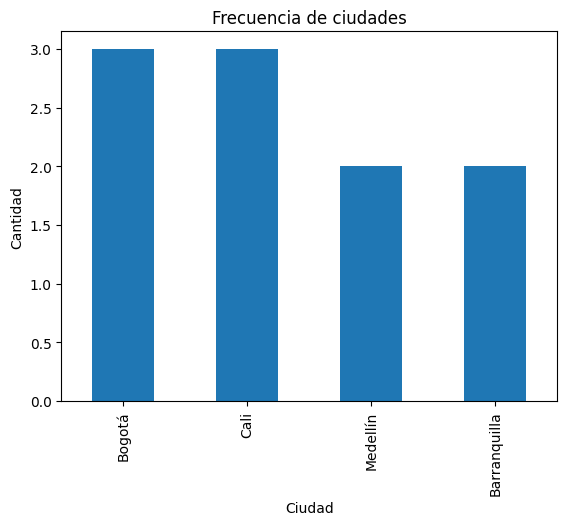

In [28]:
df["Ciudad"]. value_counts().plot(kind="bar")
plt.title("Frecuencia de ciudades")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad")
plt.show()


#**Interpretación del Gráfico**

El grafico anterior muestra la presencia de cada categoría en el dataset cuando aplicamos One-Hot, cada una de estas categorías pasa a convertirse en una columna binaria, este gráfico ayuda a entender que categorias existen y con que frecuencia aparecen.

In [40]:
X = df.drop(columns=["Compra"])
y = df["Compra"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (7, 4)
Tamaño test: (3, 4)


#**Justificacion de la división**
## ¿Por qué dividimos antes?
Porque en un flujo correcto:
- el entrenamiento se usa para aprender transformaciones,
- el test se usa para validar el comportamiento en datos aparte.

Esto prepara la lógica para explicar que las transformaciones deben ajustarse con `train` y aplicarse sobre `test`.


In [60]:
columnas_nominales = ["Ciudad"]

onehot = ColumnTransformer(
    transformers=[
        ("onehot_ciudad", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columnas_nominales)
    ],
    remainder="passthrough" 
)

X_train_transformado = onehot.fit_transform(X_train)
X_test_transformado = onehot.transform(X_test)

print("Forma train transformado:", X_train_transformado.shape)
print("Forma test transformado:", X_test_transformado.shape)

Forma train transformado: (7, 6)
Forma test transformado: (3, 6)


#Visualizamos como queda el conjunto de entrenamiento despues de la transformación

In [61]:
nombres_columnas = onehot.get_feature_names_out()
X_train_transformado_df = pd.DataFrame(X_train_transformado, columns=nombres_columnas)
X_train_transformado_df.head()

,onehot_ciudad__Ciudad_Barranquilla,onehot_ciudad__Ciudad_Bogotá,onehot_ciudad__Ciudad_Medellín,remainder__Edad,remainder__IngresoMensual,remainder__CantidadCompras
0,0.0,1.0,0.0,23.0,1200.0,2.0
1,0.0,1.0,0.0,31.0,2600.0,6.0
2,0.0,0.0,1.0,29.0,2200.0,5.0
3,1.0,0.0,0.0,22.0,1000.0,1.0
4,1.0,0.0,0.0,33.0,3100.0,7.0


#**Interpretacion**
Podemos ver como quedó el conjunto de entrenamiento después de la transformación.